# Fase 1 — Análisis Exploratorio (EDA)
### Credit Card Fraud Detection · Omar Mora Flores

**Pregunta central:** ¿Qué distingue a una transacción fraudulenta de una legítima en un
dataset con desbalance extremo de clases?

El dataset contiene **284,807 transacciones** europeas de tarjetas de crédito (2 días).
Las features `V1`–`V28` son componentes principales (PCA) anonimizados; solo `Time` y
`Amount` conservan su significado original. La variable objetivo es `Class`
(`0` = legítima, `1` = fraude).

> **Cómo ejecutar:** este notebook usa rutas relativas y localiza la raíz del proyecto
> automáticamente, así que corre igual desde `notebooks/` o desde la raíz.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Localizar la raíz del proyecto subiendo hasta encontrar data/creditcard.csv ---
ROOT = Path.cwd()
while not (ROOT / "data" / "creditcard.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "data" / "creditcard.csv"
REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

# --- Estilo de gráficos consistente ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["axes.titleweight"] = "bold"
PALETA = {"legit": "#2E86AB", "fraude": "#E63946"}
RANDOM_STATE = 42

print("Raíz del proyecto:", ROOT)
print("Dataset:", DATA.name, "| Reports →", REPORTS)

Raíz del proyecto: D:\Proyectos\Data\fraud-detection
Dataset: creditcard.csv | Reports → D:\Proyectos\Data\fraud-detection\reports


## 1.1 Carga y descripción del dataset

Cargamos el CSV y revisamos forma, tipos, primeras filas, estadísticas descriptivas y
—crítico para confiar en el resto del análisis— **valores nulos y duplicados**.

In [2]:
df = pd.read_csv(DATA)
print("Shape:", df.shape)
print("\nTipos de datos:")
print(df.dtypes.value_counts())
df.head()

Shape: (284807, 31)

Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Calidad de datos
n_nulos = int(df.isnull().sum().sum())
n_dupes = int(df.duplicated().sum())
print(f"Valores nulos totales : {n_nulos}")
print(f"Filas duplicadas      : {n_dupes}  ({100*n_dupes/len(df):.3f}% del total)")

# Estadísticas descriptivas de las columnas con significado real
df[["Time", "Amount", "Class"]].describe().T

Valores nulos totales : 0
Filas duplicadas      : 1081  (0.380% del total)


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16
Class,284807.0,0.001727,0.041527,0.0,0.0,0.0,0.000,1.00


**Hallazgo de calidad:** el dataset **no tiene valores nulos**, pero contiene
**1,081 filas duplicadas** (~0.38%). Esto contradice el supuesto inicial de "ausencia de
duplicados": deben **eliminarse en la Fase 2 (preprocessing)** antes de hacer el split,
para no inflar artificialmente ninguna clase ni filtrar información del train al test.

## 1.2 Distribución de clases — el reto del desbalance

El núcleo del problema: el fraude es un evento **raro**. Medir *accuracy* aquí es engañoso
(un modelo que prediga "legítima" siempre acertaría >99.8%). Por eso usaremos
**F1, ROC-AUC y PR-AUC** en la fase de modelado.

Legítimas (0): 284,315  (99.8273%)
Fraudes   (1):     492  (0.1727%)
Ratio de desbalance: 1 fraude por cada 577 transacciones legítimas


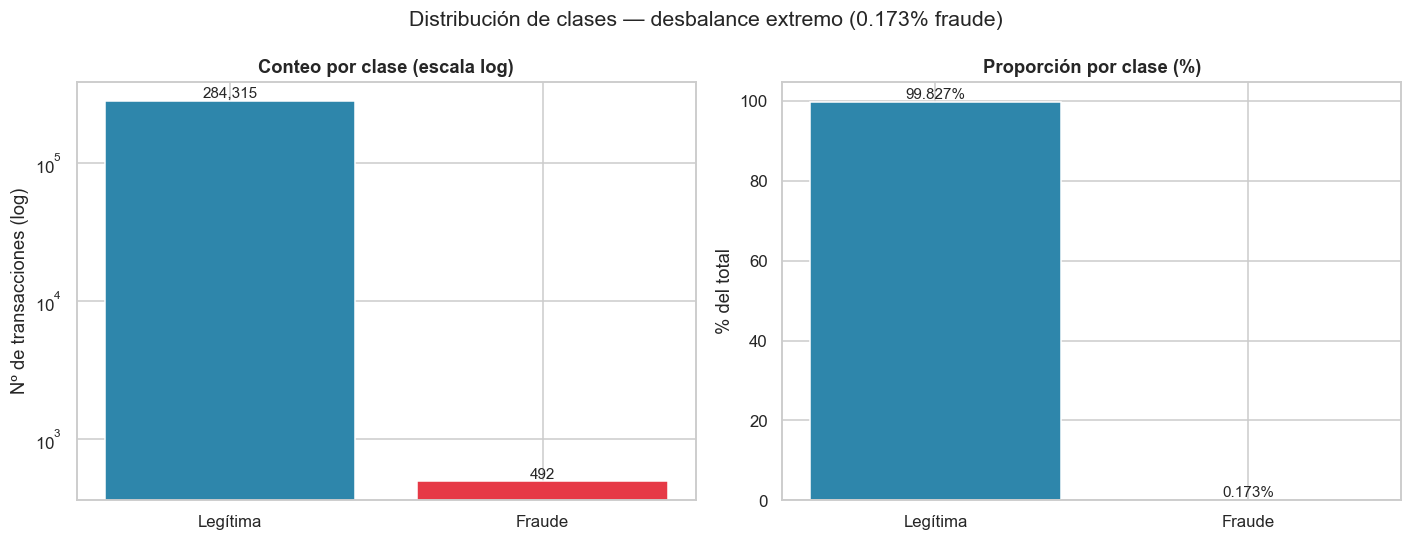

In [4]:
conteo = df["Class"].value_counts().sort_index()
pct = 100 * conteo / len(df)
print(f"Legítimas (0): {conteo[0]:>7,}  ({pct[0]:.4f}%)")
print(f"Fraudes   (1): {conteo[1]:>7,}  ({pct[1]:.4f}%)")
print(f"Ratio de desbalance: 1 fraude por cada {conteo[0]//conteo[1]:,} transacciones legítimas")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteo absoluto en escala log (si no, la barra de fraude es invisible)
bars = axes[0].bar(["Legítima", "Fraude"], conteo.values,
                   color=[PALETA["legit"], PALETA["fraude"]])
axes[0].set_yscale("log")
axes[0].set_title("Conteo por clase (escala log)")
axes[0].set_ylabel("Nº de transacciones (log)")
for b, v in zip(bars, conteo.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:,}",
                 ha="center", va="bottom", fontsize=10)

# Proporción
axes[1].bar(["Legítima", "Fraude"], pct.values,
            color=[PALETA["legit"], PALETA["fraude"]])
axes[1].set_title("Proporción por clase (%)")
axes[1].set_ylabel("% del total")
for i, v in enumerate(pct.values):
    axes[1].text(i, v, f"{v:.3f}%", ha="center", va="bottom", fontsize=10)

fig.suptitle("Distribución de clases — desbalance extremo (0.173% fraude)", fontsize=14)
fig.tight_layout()
fig.savefig(REPORTS / "01_class_distribution.png", bbox_inches="tight")
plt.show()

## 1.3 Análisis del monto (`Amount`)

¿Difieren los montos entre fraude y transacción legítima? `Amount` está muy sesgado a la
derecha, así que lo comparamos también en escala logarítmica (`log1p`).

Estadísticas de Amount por clase:
            mean  median     std       max
Legítima   88.29   22.00  250.11  25691.16
Fraude    122.21    9.25  256.68   2125.87


C:\Users\omar1\AppData\Local\Temp\claude\ipykernel_30784\1050588741.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], showfliers=False,
C:\Users\omar1\AppData\Local\Temp\claude\ipykernel_30784\1050588741.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Legítima", "Fraude"])


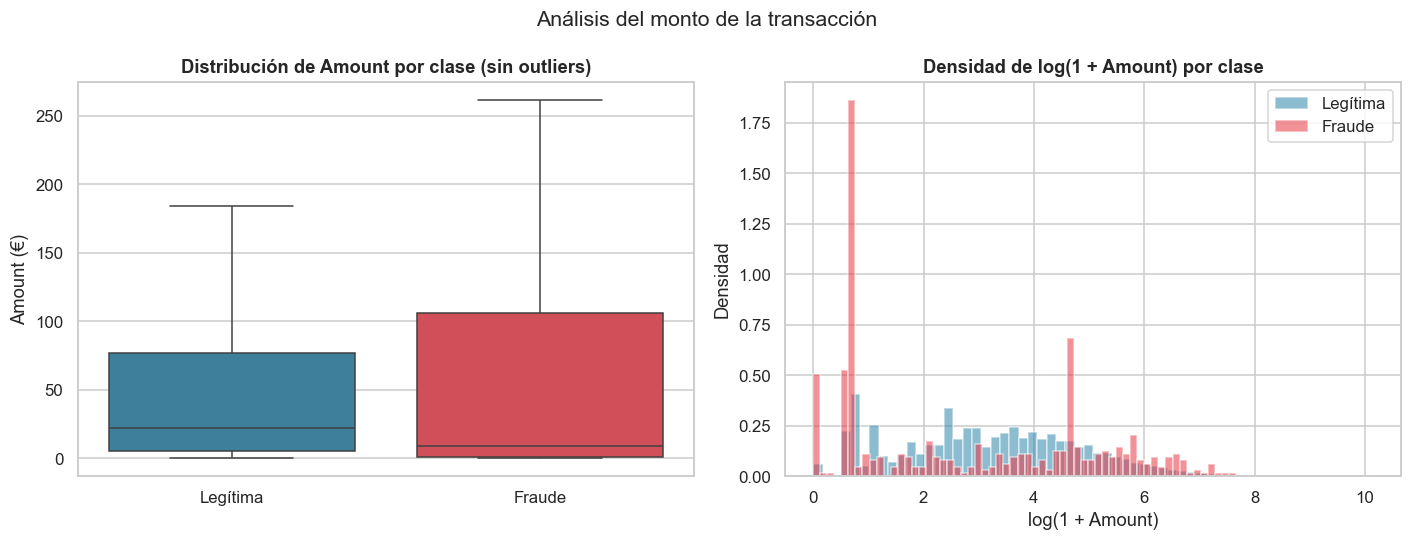

In [5]:
stats_amount = df.groupby("Class")["Amount"].agg(["mean", "median", "std", "max"])
stats_amount.index = ["Legítima", "Fraude"]
print("Estadísticas de Amount por clase:")
print(stats_amount.round(2))

df["_Amount_log"] = np.log1p(df["Amount"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot por clase (sin outliers extremos para legibilidad)
sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], showfliers=False,
            palette=[PALETA["legit"], PALETA["fraude"]])
axes[0].set_xticklabels(["Legítima", "Fraude"])
axes[0].set_title("Distribución de Amount por clase (sin outliers)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Amount (€)")

# Histograma en escala log
for c, name in [(0, "Legítima"), (1, "Fraude")]:
    axes[1].hist(df.loc[df.Class == c, "_Amount_log"], bins=60, density=True,
                 alpha=0.55, label=name,
                 color=PALETA["legit"] if c == 0 else PALETA["fraude"])
axes[1].set_title("Densidad de log(1 + Amount) por clase")
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

fig.suptitle("Análisis del monto de la transacción", fontsize=14)
fig.tight_layout()
fig.savefig(REPORTS / "02_amount_analysis.png", bbox_inches="tight")
plt.show()

**Lectura:** el monto medio del fraude (~€122) es mayor que el de las legítimas (~€88),
pero la **mediana del fraude es más baja**: muchos fraudes son de montos pequeños
(pruebas de tarjeta), con una cola de montos grandes. El monto por sí solo **no separa**
las clases — de ahí la importancia de las features PCA.

## 1.4 Análisis temporal

`Time` son segundos desde la primera transacción (cubre ~48 h). Lo convertimos a **hora del
día** para buscar patrones horarios de fraude.

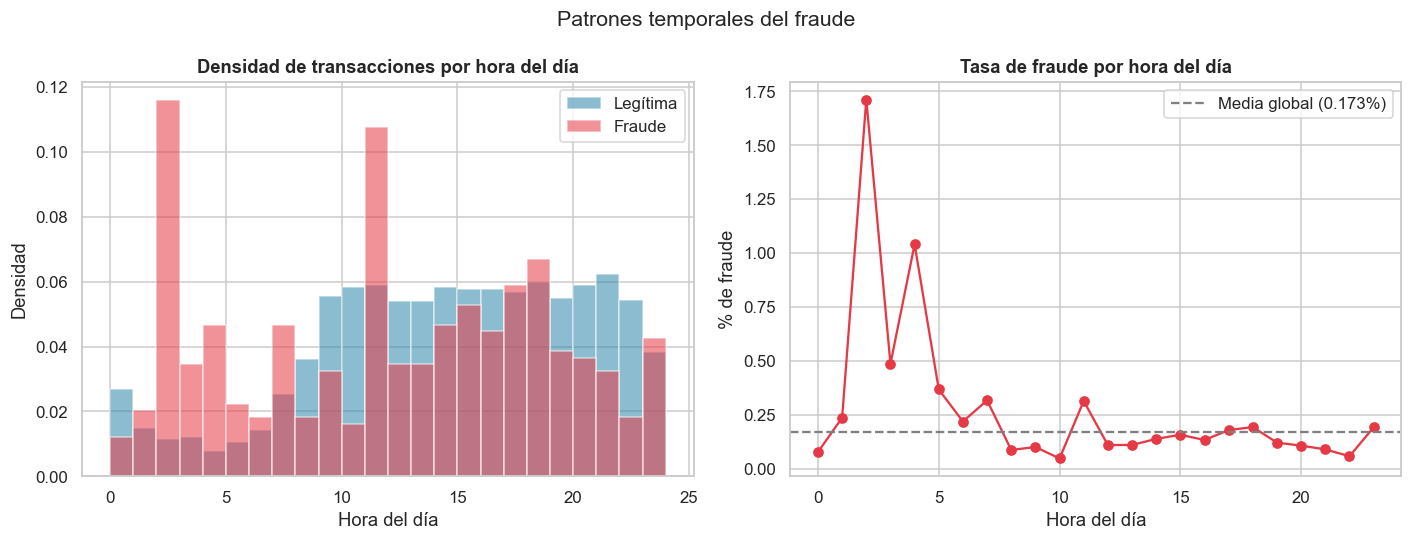

Horas con mayor tasa de fraude:
h
2    1.713
4    1.041
3    0.487
5    0.368
7    0.318
Name: tasa_fraude_%, dtype: float64


In [6]:
df["Hour"] = (df["Time"] / 3600) % 24

# Tasa de fraude por hora (fraudes / total de transacciones de esa hora)
por_hora = df.assign(h=df["Hour"].astype(int)).groupby("h")["Class"].agg(["mean", "size"])
por_hora["tasa_fraude_%"] = 100 * por_hora["mean"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Densidad de transacciones por hora, por clase
for c, name in [(0, "Legítima"), (1, "Fraude")]:
    axes[0].hist(df.loc[df.Class == c, "Hour"], bins=24, range=(0, 24), density=True,
                 alpha=0.55, label=name,
                 color=PALETA["legit"] if c == 0 else PALETA["fraude"])
axes[0].set_title("Densidad de transacciones por hora del día")
axes[0].set_xlabel("Hora del día")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Tasa de fraude por hora
axes[1].plot(por_hora.index, por_hora["tasa_fraude_%"], marker="o",
             color=PALETA["fraude"])
axes[1].axhline(100 * df["Class"].mean(), ls="--", color="gray",
                label=f"Media global ({100*df['Class'].mean():.3f}%)")
axes[1].set_title("Tasa de fraude por hora del día")
axes[1].set_xlabel("Hora del día")
axes[1].set_ylabel("% de fraude")
axes[1].legend()

fig.suptitle("Patrones temporales del fraude", fontsize=14)
fig.tight_layout()
fig.savefig(REPORTS / "03_temporal_analysis.png", bbox_inches="tight")
plt.show()

print("Horas con mayor tasa de fraude:")
print(por_hora["tasa_fraude_%"].sort_values(ascending=False).head(5).round(3))

**Lectura:** las transacciones legítimas siguen el ciclo diario (caen de madrugada),
mientras que el fraude está **relativamente más concentrado en horas de baja actividad**.
La **tasa** de fraude (no el conteo) sube en la madrugada — esto justifica crear una
bandera `Is_night` en la Fase 2.

## 1.5 Correlación de las features con la variable objetivo

Como `V1`–`V28` son componentes PCA anónimos, la correlación con `Class` nos dice cuáles
cargan más señal de fraude. Mostramos solo las de `|corr| > 0.1` para legibilidad.

Top 10 features por |correlación| con Class:
V17   -0.326
V14   -0.303
V12   -0.261
V10   -0.217
V16   -0.197
V3    -0.193
V7    -0.187
V11    0.155
V4     0.133
V18   -0.111


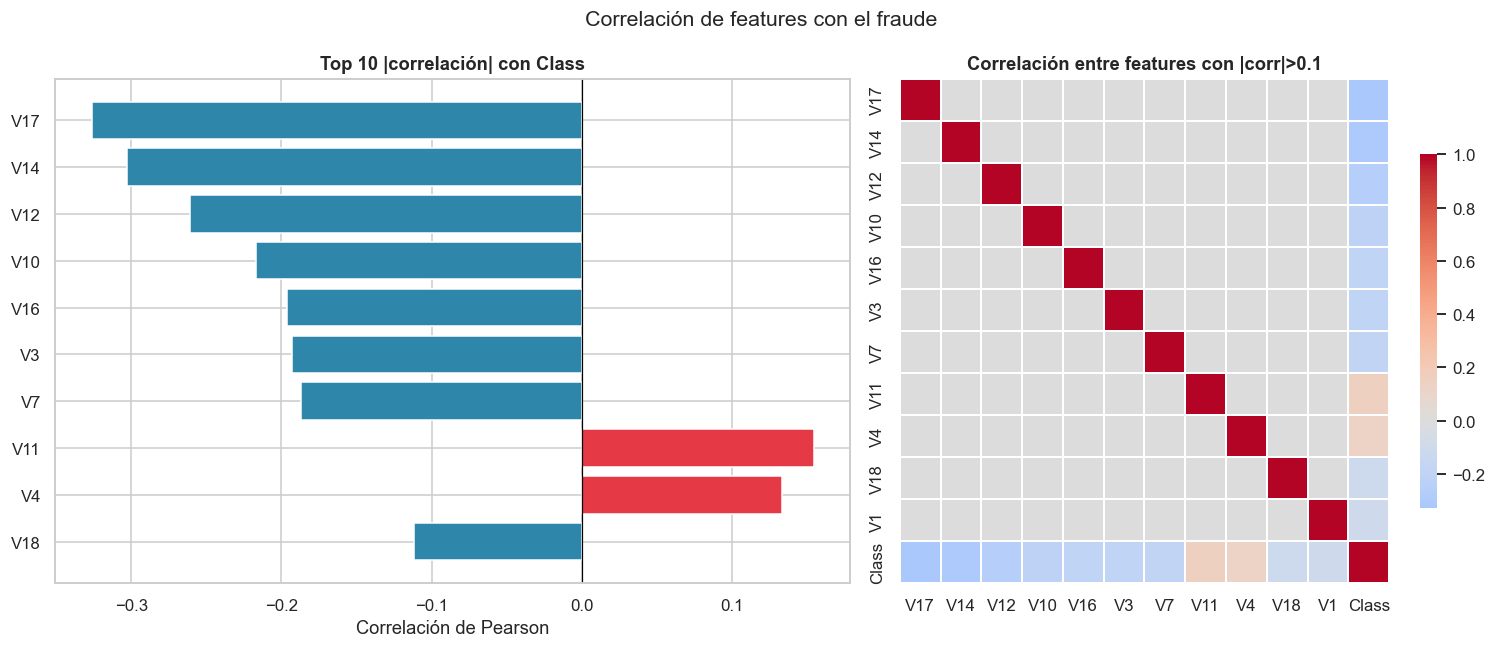

In [7]:
corr_class = (df.drop(columns=["_Amount_log", "Hour"])
                .corr(numeric_only=True)["Class"]
                .drop("Class")
                .sort_values(key=lambda s: s.abs(), ascending=False))

top10 = corr_class.head(10)
print("Top 10 features por |correlación| con Class:")
print(top10.round(3).to_string())

relevantes = corr_class[corr_class.abs() > 0.1].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         gridspec_kw={"width_ratios": [1.3, 1]})

# Barras horizontales de las top correlaciones
colores = [PALETA["fraude"] if v > 0 else PALETA["legit"] for v in top10.values]
axes[0].barh(top10.index[::-1], top10.values[::-1], color=colores[::-1])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_title("Top 10 |correlación| con Class")
axes[0].set_xlabel("Correlación de Pearson")

# Heatmap de correlación entre las features relevantes + Class
cols_hm = relevantes + ["Class"]
sns.heatmap(df[cols_hm].corr(numeric_only=True), cmap="coolwarm", center=0,
            ax=axes[1], cbar_kws={"shrink": 0.7}, linewidths=0.3)
axes[1].set_title("Correlación entre features con |corr|>0.1")

fig.suptitle("Correlación de features con el fraude", fontsize=14)
fig.tight_layout()
fig.savefig(REPORTS / "04_feature_correlation.png", bbox_inches="tight")
plt.show()

## 1.6 Conclusiones del EDA

1. **Desbalance extremo (0.173% fraude).** Obliga a usar F1 / ROC-AUC / PR-AUC (no
 accuracy) y a balancear el *train* (SMOTE o `scale_pos_weight`) en la Fase 3.
2. **1,081 duplicados** que deben eliminarse en preprocessing **antes** del split.
3. **`Amount` no separa las clases por sí solo** (medias parecidas, distribuciones
 solapadas) → se transformará con `log1p` y se escalará de forma robusta.
4. **Existe señal temporal:** la *tasa* de fraude sube en horas de baja actividad →
 justifica las features `Hour` e `Is_night`.
5. **Las features con más señal son `V17, V14, V12, V10, V16, V3, V11, V4`** — serán
 protagonistas en la importancia del modelo (Fase 3).

 **Siguiente fase:** `02_preprocessing.ipynb` — eliminar duplicados, feature engineering
(`Hour`, `Amount_log`, `Is_night`), escalado robusto, split estratificado y SMOTE solo en train.

In [8]:
df.drop(columns=["_Amount_log"], inplace=True, errors="ignore")
print("EDA completado. Figuras guardadas en:", REPORTS)
for p in sorted(REPORTS.glob("0*_*.png")):
    print(" -", p.name)

EDA completado. Figuras guardadas en: D:\Proyectos\Data\fraud-detection\reports
 - 01_class_distribution.png
 - 02_amount_analysis.png
 - 03_temporal_analysis.png
 - 04_feature_correlation.png
